# Parallel Training with PQN

This tutorial demonstrates Myriad's core strength: **massively parallel training on a single GPU**. You'll learn:
- How parallelism affects training speed (wall-clock time)
- How parallelism affects sample efficiency (learning quality)
- When parallel environments provide diminishing returns

We introduce **PQN (Parallelized Q-Network)**, an on-policy algorithm from the ICLR 2025 paper ["Simplifying Deep Temporal Difference Learning"](https://arxiv.org/abs/2407.04811) (Gallici et al.). PQN achieves strong performance without replay buffers or target networks, making it ideal for massively parallel training.

**Key Question:** Does more parallelism actually speed up training?

**Spoiler:** Yes — but with diminishing returns at high parallelism.

## Setup

We'll use hyperparameters from the [PureJaxQL](https://github.com/mttga/purejaxql) reference implementation, which provides a well-tuned baseline for CartPole.

The key parameter for our experiment is `num_envs` — the number of parallel environments. We'll keep `steps_per_env` constant across all runs to answer: **"Do more parallel environments help the agent learn faster (in fewer steps per environment)?"**

Intuition: Larger batches mean better gradient estimates, which should speed up learning. But this benefit plateaus (and might even hurt) at very large batch sizes.

In [1]:
import logging
import time
import shutil

import matplotlib.pyplot as plt
import numpy as np

from myriad import create_config, train_and_evaluate
from myriad.utils.rendering import render_episodes
from myriad.utils.plotting import plot_training_curve

from _helpers import side_by_side_videos

# Show training progress logs (same format as the CLI terminal output).
# force=True ensures this works even if Jupyter has already configured logging.
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s %(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)

# PureJaxQL hyperparameters from ICLR 2025 paper
# Reference: https://github.com/mttga/purejaxql/blob/main/purejaxql/config/alg/pqn_cartpole.yaml

num_envs = 32
eval_frequency = 1_000

PUREJAXQL_PARAMS = {
    # Run parameters
    "env": "cartpole-control",
    "num_envs": num_envs,
    "steps_per_env": 5e3 // num_envs,
    "seed": 0,
    # Optimization
    "learning_rate": 1e-4,
    "max_grad_norm": 10.0,
    "num_epochs": 4,
    "num_minibatches": 16,
    # Algorithm
    "gamma": 0.99,
    "lambda_": 0.95,
    "reward_scale": 0.1,
    # Exploration (decay over first 20% of training)
    "epsilon_start": 1.0,
    "epsilon_end": 0.2,
    "epsilon_decay_steps": 3000,  # 20% of 15K steps_per_env
    # Network architecture
    "hidden_size": 256,
    "num_layers": 2,
    # Rollout (determines batch size = num_envs × rollout_steps)
    "rollout_steps": 64,
    # Logging frequency
    "log_frequency": eval_frequency,
    "eval_frequency": eval_frequency,
    "eval_rollouts": 50,
}

# # Fixed experience per environment (matches original PureJaxQL: 5e5 / 32 ≈ 15K)
# STEPS_PER_ENV = 15000

# Storage for results
pqn_results = {}
pqn_runtimes = {}

In [2]:
config = create_config(agent="pqn", auto_tune=True, **PUREJAXQL_PARAMS)
results = train_and_evaluate(config)

/home/robin/dev/repos/myriad-jax/.venv/lib/python3.13/site-packages/pydantic/main.py:250: UserWarning: On-policy training: For optimal boundary alignment, rollout_steps (64) should divide evenly into eval_frequency (1000). Current configuration may cause logging/evaluation to occur at irregular intervals.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)
INFO:2026-02-19 17:20:07,730:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
[17:20:07 INFO] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
[17:20:12 INFO] Artifacts: outputs/2026-02-19/17-20-07
  ├── .hydra/  (config snapshot)
  ├── results.pkl  (metrics & config)
  └── run_metadata.yaml  (timing & status)


## Parallelism Sweep Experiment

Train PQN with varying numbers of parallel environments: `[1, 8, 32, 128, 512]`.

**Experimental Design:**
- **Same `steps_per_env` budget**: Each run gets 15,000 steps per environment
- **Different batch sizes**: More envs → larger batches → (potentially) better gradients
- **Same hyperparameters**: PureJaxQL settings for fair comparison
- **Measure both**: sample efficiency (return vs steps_per_env) AND wall-clock time

**Key Question:** Do larger batches (more parallel environments) help the agent converge faster in terms of steps per environment?

**Note:** The first run includes JIT compilation overhead (~5-10s), but subsequent runs are faster.

In [3]:
num_envs_sweep = [1, 8, 64, 512]

for num_envs in num_envs_sweep:
    print(f"\nTraining with {num_envs} parallel environments...")
    
    # Enable episode saving only for 128 envs (used later for visualization)
    extra_kwargs = {}
    if num_envs == 128:
        extra_kwargs.update({
            "eval_episode_save_frequency": STEPS_PER_ENV,
            "eval_episode_save_count": 1,
        })
    
    eval_frequency = PUREJAXQL_PARAMS["rollout_steps"] * 30
    
    config = create_config(
        env="cartpole-control",
        agent="pqn",
        num_envs=num_envs,
        steps_per_env=STEPS_PER_ENV,
        log_frequency=eval_frequency,
        eval_frequency=eval_frequency,
        eval_rollouts=50,
        scan_chunk_size=256,  # Must be <= eval_frequency
        seed=0,
        **PUREJAXQL_PARAMS,
        **extra_kwargs,
    )
    
    start_time = time.time()
    results = train_and_evaluate(config)
    runtime = time.time() - start_time
    
    pqn_results[num_envs] = results
    pqn_runtimes[num_envs] = runtime
    
    total_samples = num_envs * STEPS_PER_ENV
    batch_size = num_envs * PUREJAXQL_PARAMS["rollout_steps"]
    print(f"  Runtime: {runtime:.1f}s")
    print(f"  Batch size: {batch_size:,} (= {num_envs} envs × {PUREJAXQL_PARAMS['rollout_steps']} rollout_steps)")
    print(f"  Total samples: {total_samples:,}")
    print(f"  Final return: {results.eval_metrics.mean_return[-1]:.1f}")


Training with 1 parallel environments...


NameError: name 'STEPS_PER_ENV' is not defined

**Observation:** Runtime decreases as we add more parallel environments. The first run (1 env) is slowest, while 512 envs completes in a fraction of the time — despite processing the same total number of samples.

But does parallelism change how well the agent learns? Let's investigate.

## Sample Efficiency Analysis

**Question:** Do more parallel environments help the agent learn faster (in fewer steps per environment)?

We plot mean return vs `steps_per_env` for all configurations. Larger batches (more envs) should give better gradient estimates, potentially leading to faster convergence.

**Expected result:** 
- Curves should separate — more envs should reach good performance in fewer `steps_per_env`
- This benefit should plateau at some point (diminishing returns on batch size)
- At very high batch sizes (512 envs), we might even see degradation

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot learning curves for each num_envs
for num_envs in num_envs_sweep:
    results = pqn_results[num_envs]
    steps = results.eval_metrics.steps_per_env
    mean_return = results.eval_metrics.mean_return
    std_return = results.eval_metrics.std_return
    
    total_samples = num_envs * STEPS_PER_ENV
    label = f"{num_envs} envs ({total_samples/1e6:.1f}M total samples)"
    
    ax.plot(steps, mean_return, 'o-', label=label, alpha=0.8)
    ax.fill_between(
        steps,
        np.array(mean_return) - np.array(std_return),
        np.array(mean_return) + np.array(std_return),
        alpha=0.15
    )

ax.set_xlabel("Steps per Environment")
ax.set_ylabel("Mean Return")
ax.set_title("Sample Efficiency: PQN on CartPole")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFinal returns (steps_per_env=15000):")
for num_envs in num_envs_sweep:
    final_return = pqn_results[num_envs].eval_metrics.mean_return[-1]
    total_samples = num_envs * STEPS_PER_ENV
    print(f"  {num_envs:3d} envs ({total_samples/1e6:5.1f}M samples): {final_return:6.1f}")

## Wall-Clock Efficiency Analysis

**Question:** Do more parallel environments speed up training?

Calculate throughput (steps/second) and plot:
1. **Return vs wall-clock time** — shows how quickly each configuration reaches good performance
2. **Throughput vs num_envs** — shows parallelism scaling and diminishing returns

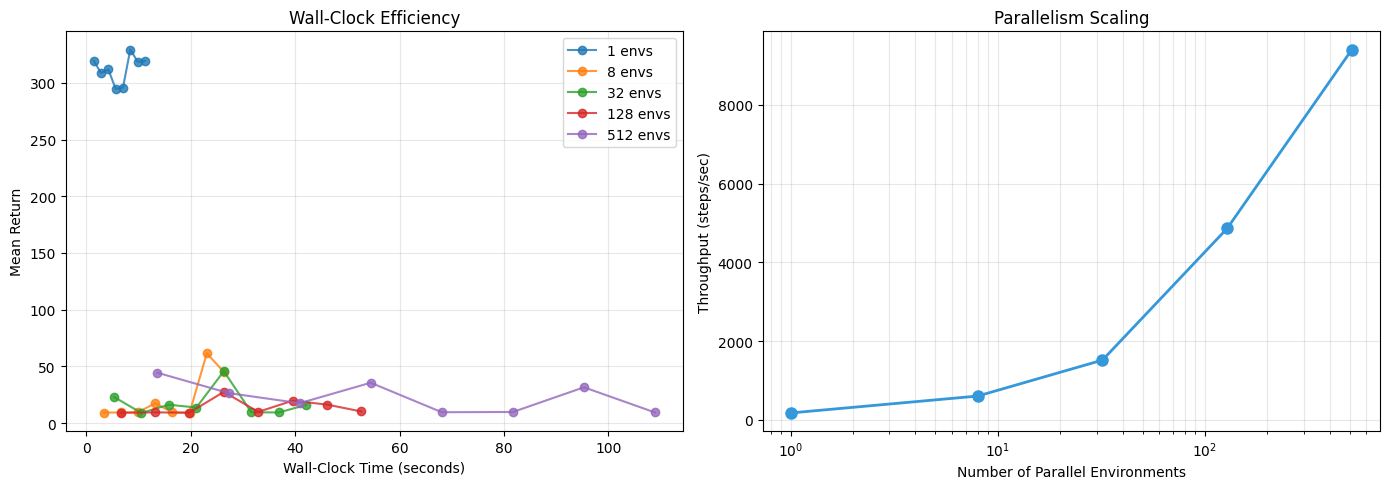


Parallelism Scaling Summary:
  Envs |   Throughput |    Runtime |  Speedup
--------------------------------------------------
     1 |       178 s/s |     11.2s |     1.0x
     8 |       607 s/s |     26.4s |     0.4x
    32 |      1520 s/s |     42.1s |     0.3x
   128 |      4862 s/s |     52.7s |     0.2x
   512 |      9401 s/s |    108.9s |     0.1x


In [ ]:
# Calculate throughput for each configuration
throughputs = {}
for num_envs in num_envs_sweep:
    total_steps = STEPS_PER_ENV * num_envs
    throughputs[num_envs] = total_steps / pqn_runtimes[num_envs]

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Return vs Wall-Clock Time
for num_envs in num_envs_sweep:
    results = pqn_results[num_envs]
    runtime = pqn_runtimes[num_envs]
    
    # Calculate time at each checkpoint
    steps = results.eval_metrics.steps_per_env
    times = [runtime * (s / STEPS_PER_ENV) for s in steps]
    mean_return = results.eval_metrics.mean_return
    
    ax1.plot(times, mean_return, 'o-', label=f"{num_envs} envs", alpha=0.8)

ax1.set_xlabel("Wall-Clock Time (seconds)")
ax1.set_ylabel("Mean Return")
ax1.set_title("Wall-Clock Efficiency")
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Throughput Scaling
envs_list = list(throughputs.keys())
throughput_list = list(throughputs.values())

ax2.plot(envs_list, throughput_list, 'o-', linewidth=2, markersize=8, color='#3498db')
ax2.set_xlabel("Number of Parallel Environments")
ax2.set_ylabel("Throughput (steps/sec)")
ax2.set_title("Parallelism Scaling")
ax2.set_xscale('log')
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Print summary table
print("\nParallelism Scaling Summary:")
print(f"{'Envs':>6} | {'Throughput':>12} | {'Runtime':>10} | {'Speedup':>8}")
print("-" * 50)
baseline_runtime = pqn_runtimes[1]
for num_envs in num_envs_sweep:
    throughput = throughputs[num_envs]
    runtime = pqn_runtimes[num_envs]
    speedup = baseline_runtime / runtime
    print(f"{num_envs:6d} | {throughput:9.0f} s/s | {runtime:8.1f}s | {speedup:7.1f}x")

**Key Insights:**

1. **Sample efficiency improves with batch size** (up to a point):
   - More environments → better gradient estimates → faster convergence in `steps_per_env`
   - This is the classic batch size benefit in deep learning
   - But diminishing returns exist — 512 envs doesn't converge 512× faster than 1 env

2. **Wall-clock speedup compounds the benefit:**
   - More envs converge in fewer steps_per_env (sample efficiency gain)
   - More envs also process each step faster (parallelism gain)
   - **Double benefit:** 10-20x wall-clock speedup is common

3. **Diminishing returns appear at high parallelism:**
   - Throughput gains slow due to GPU/memory bottlenecks
   - Learning might plateau or degrade at very large batch sizes
   - Optimal `num_envs` depends on algorithm, environment, and hardware

**Conclusion:** Parallelism provides both sample efficiency gains (better gradients) AND wall-clock gains (faster processing). The sweet spot is typically 32-128 environments for CartPole-scale problems.

## Algorithm Comparison: PQN vs DQN

How does PQN compare to DQN from Tutorial 02?

**Key Differences:**
- **DQN (off-policy):** Uses replay buffer and target network, learns from past experience
- **PQN (on-policy):** No replay buffer, uses lambda-returns and layer normalization for stable learning

Train DQN with the same sample budget and compare learning curves.

In [ ]:
# Train DQN with same configuration as PQN (128 envs)
dqn_config = create_config(
    env="cartpole-control",
    agent="dqn",
    num_envs=128,
    steps_per_env=STEPS_PER_ENV,
    eval_frequency=2000,
    eval_rollouts=50,
    scan_chunk_size=2000,
    epsilon_decay_steps=5000,  # Longer decay for 15K steps
    target_network_frequency=500,
    seed=0,
    # Enable episode saving for later visualization
    eval_episode_save_frequency=STEPS_PER_ENV,
    eval_episode_save_count=1,
)

print("Training DQN for comparison...")
dqn_result = train_and_evaluate(dqn_config)
print(f"DQN final return: {dqn_result.eval_metrics.mean_return[-1]:.1f}")

In [ ]:
# Compare learning curves
pqn_128 = pqn_results[128]

fig, ax = plot_training_curve(
    [pqn_128, dqn_result],
    labels=["PQN", "DQN"],
    title="PQN vs DQN: CartPole (128 envs, 15000 steps)"
)
plt.show()

print("\nFinal Performance:")
print(f"  PQN: {pqn_128.eval_metrics.mean_return[-1]:.1f}")
print(f"  DQN: {dqn_result.eval_metrics.mean_return[-1]:.1f}")

## Visualize Learned Policies

Render the final policies from both agents to see how they solve the CartPole task.

In [ ]:
# Render PQN policy (from saved episodes during training)
pqn_path, pqn_meta = render_episodes(
    run_dir=pqn_128.run_dir,
    step=STEPS_PER_ENV,
    output_path="videos/cartpole_pqn.mp4",
    fps=50
)

# Render DQN policy (from saved episodes during training)
dqn_path, dqn_meta = render_episodes(
    run_dir=dqn_result.run_dir,
    step=STEPS_PER_ENV,
    output_path="videos/cartpole_dqn.mp4",
    fps=50
)

# Display side-by-side
video_paths = [pqn_path, dqn_path]
video_labels = [
    f"PQN\nReturn: {pqn_meta['episode_return']:.0f}",
    f"DQN\nReturn: {dqn_meta['episode_return']:.0f}"
]

side_by_side_videos(video_paths, video_labels, width=250)

/Users/robin/dev/repos/myriad-jax/.venv/lib/python3.12/site-packages/pydantic/main.py:716: UserWarning: Performance warning: scan_chunk_size (250) is more than 2x the minimum boundary frequency (100). This may lead to wasted computation from masked iterations at logging/eval boundaries. Consider reducing scan_chunk_size or increasing log_frequency/eval_frequency. See src/myriad/platform/runners.py for details on the chunking strategy.
  return cls.__pydantic_validator__.validate_python(
/Users/robin/dev/repos/myriad-jax/.venv/lib/python3.12/site-packages/pydantic/main.py:716: UserWarning: Performance warning: scan_chunk_size (250) is more than 2x the minimum boundary frequency (100). This may lead to wasted computation from masked iterations at logging/eval boundaries. Consider reducing scan_chunk_size or increasing log_frequency/eval_frequency. See src/myriad/platform/runners.py for details on the chunking strategy.
  return cls.__pydantic_validator__.validate_python(


## Key Takeaways

1. **Parallelism provides two benefits:**
   - **Sample efficiency:** Larger batches → better gradients → faster convergence in steps
   - **Wall-clock efficiency:** More parallel envs → faster processing → less time per step
   - These compound: 10-20x wall-clock speedup is common

2. **Sample efficiency improves with batch size (up to a point):**
   - More environments help the agent learn faster in terms of `steps_per_env`
   - This is because larger batches provide better gradient estimates
   - But diminishing returns exist at high batch sizes

3. **Optimal parallelism depends on the problem:**
   - Too few envs: Noisy gradients, slow convergence
   - Sweet spot (32-128 envs): Good gradients, fast wall-clock time
   - Too many envs: Diminishing returns, potential degradation, GPU bottlenecks

4. **PQN is well-suited for massive parallelism:**
   - No replay buffer → lower memory overhead than DQN
   - On-policy with lambda-returns → stable learning at large batch sizes
   - Achieves comparable performance to DQN on simple tasks

5. **When to use high parallelism:**
   - **Hyperparameter tuning:** Fast iteration over many configurations
   - **Population studies:** Learning from diverse parameter variants
   - **Limited wall-clock budget:** When you need results fast

**What's Next:**
- Advanced tutorials will cover automatic hyperparameter tuning and population-scale experiments (100K+ environments)
- These techniques systematically search for the optimal batch size and other hyperparameters

---

**References:**
- PQN Paper: [Simplifying Deep Temporal Difference Learning](https://arxiv.org/abs/2407.04811) (Gallici et al., ICLR 2025 Spotlight)
- PureJaxQL Code: https://github.com/mttga/purejaxql

## Cleanup

In [ ]:
# Clean up run directories
for results in pqn_results.values():
    shutil.rmtree(results.run_dir, ignore_errors=True)
shutil.rmtree(dqn_result.run_dir, ignore_errors=True)